# 05. Acquisition Funnel

**Notebook goal:** marketing funnel conversion by channel, the funnel efficiency improving with scale counter narrative, whether declared seller attributes at signup predict real future performance, and the unlabeled `lead_behaviour_profile` discovery finding.

**Source:** `analysis_master.csv`, `marketing_qualified_leads_dataset.csv` and `closed_deals_dataset.csv`.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 11,
})
ACCENT = "#2E5EAA"
ACCENT_WARN = "#C0392B"
NEUTRAL = "#B0B0B0"

In [2]:
mql = pd.read_csv("marketing_qualified_leads_dataset.csv")
deals = pd.read_csv("closed_deals_dataset.csv")
am = pd.read_csv("analysis_master.csv", low_memory=False)
print(f"Leads: {len(mql):,}   Won deals: {len(deals):,}")

Leads: 8,000   Won deals: 842


Which leads actually converted, joined once and reused below.

In [3]:
leads_with_outcome = mql.merge(deals[["mql_id"]], on="mql_id", how="left", indicator=True)
leads_with_outcome["won"] = leads_with_outcome["_merge"] == "both"
print(f"Overall conversion rate: {leads_with_outcome['won'].mean()*100:.2f}%")

Overall conversion rate: 10.53%


## Conversion rate by acquisition channel

`origin` is missing for 60 leads. Unlike `unknown` (a real value the tracking system recorded), these 60 have no origin recorded at all so excluded from this specific chart rather than plotted alongside real channels, since invest more in not specified isn't an actionable recommendation. They're kept in the underlying data, just not charted here.

In [4]:
by_origin = (leads_with_outcome.dropna(subset=["origin"])
             .groupby("origin")["won"].agg(conversion_rate="mean", n="count"))
by_origin["conversion_rate"] = by_origin["conversion_rate"] * 100
by_origin = by_origin.sort_values("conversion_rate", ascending=False)
by_origin

,conversion_rate,n
origin,,
unknown,16.287534,1099
paid_search,12.295082,1586
organic_search,11.803136,2296
direct_traffic,11.222445,499
referral,8.450704,284
social,5.555556,1350
display,5.084746,118
other_publicities,4.615385,65
email,3.042596,493


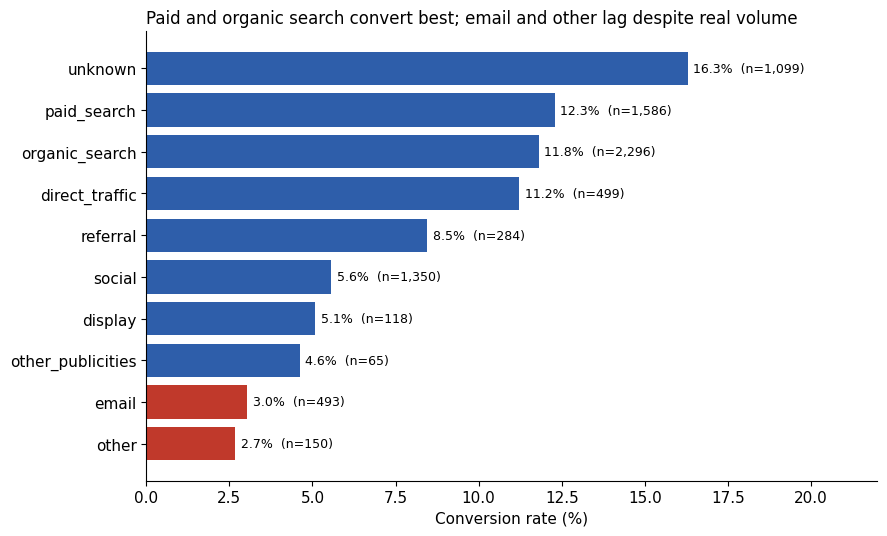

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
y_pos = np.arange(len(by_origin))
colors = [ACCENT_WARN if o in ["email", "other"] else ACCENT for o in by_origin.index]
bars = ax.barh(y_pos, by_origin["conversion_rate"], color=colors)
ax.bar_label(bars, labels=[f"{v:.1f}%  (n={n:,})" for v, n in zip(by_origin["conversion_rate"], by_origin["n"])],
             padding=4, fontsize=9)
ax.set_yticks(y_pos)
ax.set_yticklabels(by_origin.index)
ax.invert_yaxis()
ax.set_xlim(0, by_origin["conversion_rate"].max() * 1.35)
ax.set_xlabel("Conversion rate (%)")
ax.set_title("Paid and organic search convert best; email and other lag despite real volume", fontsize=12, loc="left")
plt.tight_layout()
plt.show()

**Finding:** overall conversion is 10.5%, but channel matters.

- `paid_search` (12.3%) and `organic_search` (11.8%) convert well above average, while `email` (3.0%) and `other` (2.7%) lag badly despite reasonable lead volume (493 and 150 leads respectively which is not too small to trust).

- `unknown`'s high rate (16.3%) is worth a caveat rather than a celebration: an unlabeled channel converting best is more likely a tracking gap for specific high intent traffic than a channel worth deliberately investing more in.

## Funnel efficiency over time : the counter narrative to notebook 01

Notebook 01 showed delivery quality did not hold steady as order volume grew. Does acquisition efficiency show the same strain, or the opposite?

In [7]:
mql["first_contact_date"] = pd.to_datetime(mql["first_contact_date"])
mql["month"] = mql["first_contact_date"].dt.to_period("M").astype(str)
monthly_leads = mql.merge(deals[["mql_id"]], on="mql_id", how="left", indicator=True)
monthly_leads["won"] = monthly_leads["_merge"] == "both"

EXCLUDE_MONTHS = ["2017-06"]
monthly_funnel = (monthly_leads[~monthly_leads["month"].isin(EXCLUDE_MONTHS)]
                   .groupby("month")
                   .agg(n_leads=("mql_id", "count"), conversion_rate=("won", "mean"))
                   .reset_index())
monthly_funnel["conversion_rate"] = monthly_funnel["conversion_rate"] * 100
monthly_funnel

,month,n_leads,conversion_rate
0,2017-07,239,0.836820
1,2017-08,386,2.331606
2,2017-09,312,2.243590
3,2017-10,416,3.365385
4,2017-11,445,4.044944
5,2017-12,200,5.500000
6,2018-01,1141,13.321648
7,2018-02,1028,14.494163
8,2018-03,1174,14.224872
9,2018-04,1352,13.535503


**Data coverage note before plotting:** the lead data only runs through May 2018, notably shorter than the main order data (which extends to October 2018) so this chart's x-axis is genuinely shorter than notebook 01's, not a cropped view of the same range.

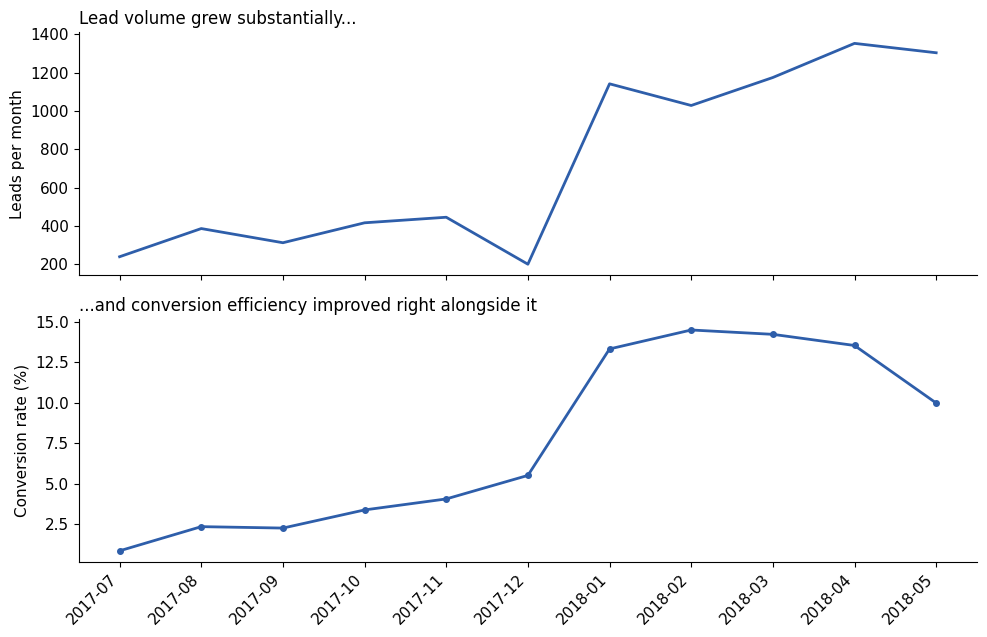

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
x_pos = np.arange(len(monthly_funnel))

ax1.plot(x_pos, monthly_funnel["n_leads"], color=ACCENT, linewidth=2)
ax1.set_ylabel("Leads per month")
ax1.set_title("Lead volume grew substantially...", fontsize=12, loc="left")

ax2.plot(x_pos, monthly_funnel["conversion_rate"], color=ACCENT, linewidth=2, marker="o", markersize=4)
ax2.set_ylabel("Conversion rate (%)")
ax2.set_title("...and conversion efficiency improved right alongside it", fontsize=12, loc="left")

ax2.set_xticks(x_pos)
ax2.set_xticklabels(monthly_funnel["month"], rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Finding:** monthly conversion rate rose from under 1% in mid 2017 to 13-14% by early 2018, even as lead volume grew from a few hundred to over 1,300 per month.

- This is the opposite pattern from notebook 01's operational dips (Nov 2017, Mar 2018) which means acquisition got more efficient with scale, while delivery operations didn't uniformly keep pace over the same period.

- This pairing (not either chart alone) is the strongest evidence for the growth vs. quality tension: growth pressure didn't hurt every part of the business the same way, which is a more precise and more defensible claim than growth strained the marketplace in general.

**One more likely extraction artifact:** May 2018's conversion rate drops to 10% from the 13-14% run before it. Time to close has a long tail (mean 48 days, some deals over a year) so if the underlying dataset was pulled shortly after May 31, 2018, late May leads simply haven't had time to convert yet, understating May's true eventual rate. Read the last point with that caveat rather than as a real reversal.

## How much of the marketplace does the funnel actually explain?

Before reading too much into declared attributes predict performance, it's worth being upfront about how small the overlap between funnel data and real active sellers actually is.

In [9]:
active_sellers = am.dropna(subset=["seller_id"])["seller_id"].unique()
overlap_sellers = deals[deals["seller_id"].isin(active_sellers)]["seller_id"].unique()

print(f"Active sellers in the marketplace: {len(active_sellers):,}")
print(f"Won deals that became an active seller: {len(overlap_sellers):,} of {len(deals):,} won deals ({len(overlap_sellers)/len(deals)*100:.1f}%)")
print(f"Active sellers with any funnel record at all: {len(overlap_sellers):,} of {len(active_sellers):,} ({len(overlap_sellers)/len(active_sellers)*100:.1f}%)")

Active sellers in the marketplace: 3,085
Won deals that became an active seller: 379 of 842 won deals (45.0%)
Active sellers with any funnel record at all: 379 of 3,085 (12.3%)


**Finding:** only 12.3% of active sellers have any funnel record, and only 45.0% of won deals ever become an active seller.

- This is why `funnel_summary` style data stays a standalone story rather than merging into the main satisfaction/delivery narrative.

- Confirmed again here, independently, a third time across the project. Every finding below applies only to this specific 379 seller overlap, not the marketplace as a whole.

## Do declared signup attributes predict real future performance?

For the 379 sellers where funnel and real order data connect, joined directly against `analysis_master.csv`'s seller level columns.

In [10]:
seller_perf = am.dropna(subset=["seller_id"]).drop_duplicates(subset=["seller_id"])[
    ["seller_id", "seller_pct_late", "seller_avg_order_value"]]
funnel_perf = deals.merge(seller_perf, on="seller_id", how="inner")
print(f"Sellers in this analysis: {len(funnel_perf)}")

Sellers in this analysis: 379


In [11]:
lead_type_perf = (funnel_perf.groupby("lead_type")["seller_pct_late"]
                   .agg(late_rate="mean", n="count").sort_values("late_rate"))
lead_type_perf["late_rate"] = lead_type_perf["late_rate"] * 100
lead_type_perf

,late_rate,n
lead_type,,
online_top,1.626984,6
industry,2.843633,41
online_small,3.542691,28
online_beginner,4.428936,21
online_big,5.305675,78
online_medium,8.125261,172
offline,8.992063,30


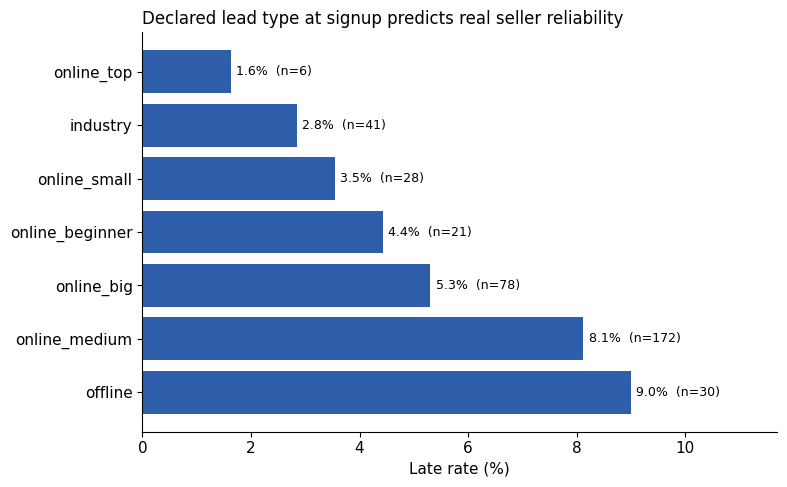

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(lead_type_perf))
bars = ax.barh(y_pos, lead_type_perf["late_rate"], color=ACCENT)
ax.bar_label(bars, labels=[f"{v:.1f}%  (n={n})" for v, n in zip(lead_type_perf["late_rate"], lead_type_perf["n"])],
             padding=4, fontsize=9)
ax.set_yticks(y_pos)
ax.set_yticklabels(lead_type_perf.index)
ax.invert_yaxis()
ax.set_xlim(0, lead_type_perf["late_rate"].max() * 1.3)
ax.set_xlabel("Late rate (%)")
ax.set_title("Declared lead type at signup predicts real seller reliability", fontsize=12, loc="left")
plt.tight_layout()
plt.show()

**Finding:** a real, fairly clean gradient.

- `online_top` (1.6%, though only 6 sellers) and `industry` (2.8%) outperform `online_medium` (8.1%) and `offline` (9.0%).

- More established businesses at signup do tend to become more reliable sellers.

- `online_top`'s n=6 is genuinely too small to lean on heavily, but the broader gradient across the other categories (each with 21 to 172 sellers) holds up.

In [13]:
business_type_perf = funnel_perf.groupby("business_type").agg(
    late_rate=("seller_pct_late", "mean"),
    avg_order_value=("seller_avg_order_value", "mean"),
    n=("seller_id", "count"),
)
business_type_perf["late_rate"] = business_type_perf["late_rate"] * 100
business_type_perf

,late_rate,avg_order_value,n
business_type,,,
manufacturer,8.371970,163.487526,90
reseller,5.890988,187.659499,286


## Manufacturers vs. Resellers

What is the late rate and average order value based on these two categories?

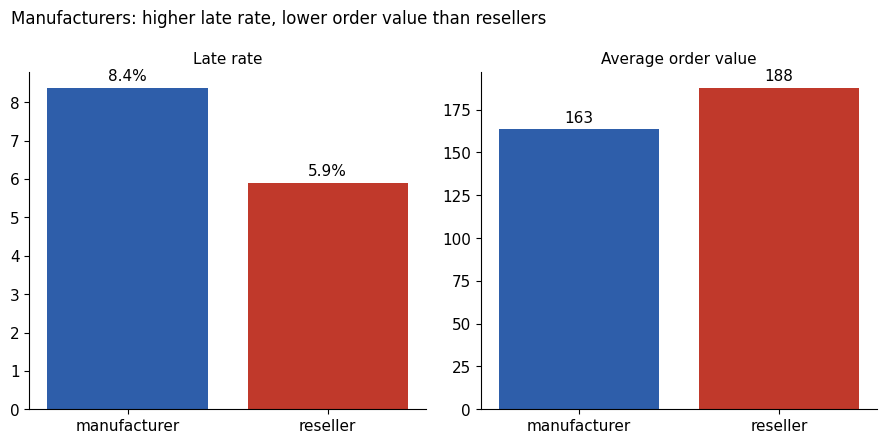

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].bar(business_type_perf.index, business_type_perf["late_rate"], color=[ACCENT, ACCENT_WARN])
axes[0].bar_label(axes[0].containers[0], fmt="%.1f%%", padding=3)
axes[0].set_title("Late rate", fontsize=11)

axes[1].bar(business_type_perf.index, business_type_perf["avg_order_value"], color=[ACCENT, ACCENT_WARN])
axes[1].bar_label(axes[1].containers[0], fmt="%.0f", padding=3)
axes[1].set_title("Average order value", fontsize=11)

fig.suptitle("Manufacturers: higher late rate, lower order value than resellers", fontsize=12, x=0.02, ha="left")
plt.tight_layout()
plt.show()

**Finding:** manufacturers have a higher late rate (8.4% vs. 5.9%) and lower average order value (163 Real vs. 188 Real) than resellers.

- Possible if manufacturers are more often shipping custom or made to order items, but this project has no direct way to confirm that explanation from the data available. Stated as a real pattern with a speculative mechanism, not a proven one.

## Discovery finding: an unlabeled internal tag that predicts real outcomes

`lead_behaviour_profile` is an internal sales team tag (`eagle`, `cat`, `shark`, `wolf`, and a couple of rare combined tags) whose actual meaning was never documented anywhere in this dataset or its accompanying materials. Whatever it represents, does it correlate with anything real?

In [15]:
profile_perf = (funnel_perf.groupby("lead_behaviour_profile")["seller_pct_late"]
                .agg(late_rate="mean", n="count").sort_values("late_rate"))
profile_perf["late_rate"] = profile_perf["late_rate"] * 100

profile_perf = profile_perf[profile_perf["n"] >= 10]
profile_perf

,late_rate,n
lead_behaviour_profile,,
eagle,4.821031,50
cat,6.261235,183
shark,11.929868,10
wolf,12.807829,43


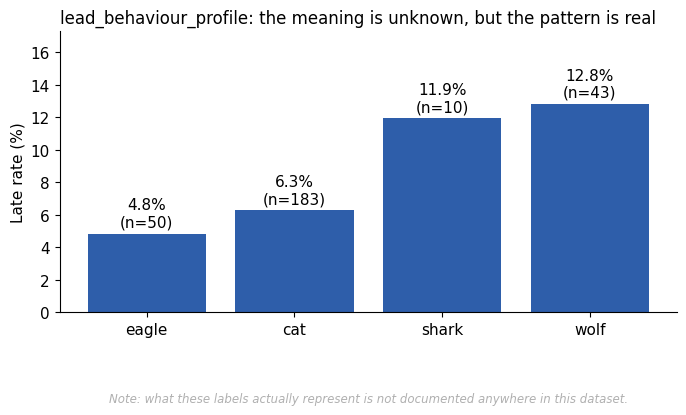

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(profile_perf.index, profile_perf["late_rate"], color=ACCENT)
ax.bar_label(bars, labels=[f"{v:.1f}%\n(n={n})" for v, n in zip(profile_perf["late_rate"], profile_perf["n"])], padding=3)
ax.set_ylim(0, profile_perf["late_rate"].max() * 1.35)
ax.set_ylabel("Late rate (%)")
ax.set_title("lead_behaviour_profile: the meaning is unknown, but the pattern is real", fontsize=12, loc="left")
ax.text(0.5, -0.32, "Note: what these labels actually represent is not documented anywhere in this dataset.",
        transform=ax.transAxes, ha="center", fontsize=8.5, style="italic", color=NEUTRAL)
plt.tight_layout()
plt.show()

**Finding:** `wolf` (12.8% late) and `shark` (11.9%, small n=10) sellers perform notably worse than `cat` (6.3%) and `eagle` (4.8%) which is a real, fairly large spread (nearly 3x between best and worst), despite knowing the meaning of them or how they were assigned.

- This is exactly the kind of finding worth flagging rather than dropping just because it's unexplained: worth a direct question to Olist or whoever owns this sales process.

- If this tag is genuinely predictive, it may already be a useful internal signal that's simply never been formally validated or documented.

## A smaller side note: sales rep concentration

Mirrors notebook 01's seller-concentration finding, on the acquisition side. `closed_deals_dataset.csv` actually has two rep ID columns : `sdr_id` (the rep who initially qualifies a lead) and `sr_id` (the rep who closes it). This chart uses `sr_id`, since who closed the deal is the more meaningful concentration question.

In [18]:
rep_counts = deals["sr_id"].value_counts()
print(f"{len(rep_counts)} sales reps handled all {len(deals)} won deals")
print(f"Top rep alone closed {rep_counts.iloc[0]} deals ({rep_counts.iloc[0]/len(deals)*100:.1f}%)")

22 sales reps handled all 842 won deals
Top rep alone closed 133 deals (15.8%)


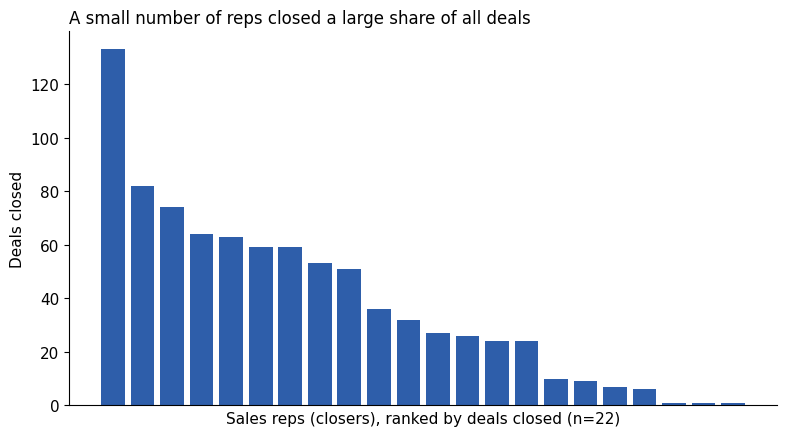

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(len(rep_counts)), rep_counts.values, color=ACCENT)
ax.set_xlabel(f"Sales reps (closers), ranked by deals closed (n={len(rep_counts)})")
ax.set_ylabel("Deals closed")
ax.set_title("A small number of reps closed a large share of all deals", fontsize=12, loc="left")
ax.set_xticks([])
plt.tight_layout()
plt.show()

**Finding:** 22 sales reps closed all 842 deals, and the top rep alone closed 15.8% of them, a concentration pattern echoing notebook 01's seller-volume finding.

- Included as a minor supporting note, not a headline chart; there's no data here on rep tenure, quota, or team size to say whether this concentration is a strength (a genuinely excellent rep) or a risk (over reliance on one person).

## Summary

1. Channel matters for conversion : paid/organic search well above average, email and other well below, despite real volume in both directions.
2. Funnel efficiency improved substantially as lead volume scaled up : the direct counter narrative to notebook 01's operational dips, and the second half of the growth vs. quality story.
3. The funnel to real seller overlap is genuinely small (12.3%) : every finding here applies to that overlap specifically, not the marketplace as a whole.
4. Declared attributes at signup (`lead_type`, `business_type`) do predict real future seller performance : a genuine closing the loop finding with early-warning potential.
5. An undocumented internal tag (`lead_behaviour_profile`) correlates strongly with real outcomes despite an unknown mechanism : flagged for the team rather than dropped.